# Plot1 - CarbonSavings vs. MakeSpan

## Line plot and Box plot

In [240]:
import pandas as pd
import glob
import os
location = "AU-SA"
# location = "California"
#############
folder_type = "Homogen"
# folder_type = "Heterogen"
# folder_type = "Heterogen_Energy"
############
mixed_objective = False # for energy-aware optimization that had a tie braker of carbon term
############
# root_dir = f"../Logs/GeneralExp"
root_dir = f"../Logs/GeneralExpv2/{folder_type}/{location}"
num_jobs = 10
num_servers = 5
num_operations = 3
#############

# Define the pattern
pattern = f"{num_jobs}J_{num_servers}S_{num_operations}O_MeanOp=7_v*.csv"
if mixed_objective:
    pattern = f"{num_jobs}J_{num_servers}S_{num_operations}O_MeanOp=7_MixedObjective_v*.csv"

# Get list of matching files
csv_files = glob.glob(f"{root_dir}/{pattern}")

# Read and concatenate all files
df_union = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

print(f"✅ Loaded and merged {len(csv_files)} files. Final shape: {df_union.shape}")

✅ Loaded and merged 8 files. Final shape: (4320, 23)


In [241]:
df_logs = df_union[["Instance", "IsCarbonAware", "MaxMakeSpan", "MinMakeSpan", "SlackCoeff", "Makespan", "CarbonConsumption(g)", "EnergyConsumption(kWh)"]]

In [242]:
df_logs.head(12)

,Instance,IsCarbonAware,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g),EnergyConsumption(kWh)
0,0,False,672,111,1.0,111,4898.25,37.5
1,0,True,111,111,1.0,111,2448.25,37.5
2,0,True,167,111,1.5,120,2124.75,37.5
3,0,True,222,111,2.0,121,2122.50,37.5
4,1,False,672,142,1.0,142,7015.00,58.0
5,1,True,142,142,1.0,142,3741.50,58.0
6,1,True,213,142,1.5,144,4058.25,58.0
7,1,True,284,142,2.0,284,4983.00,58.0
8,2,False,672,123,1.0,123,5554.50,60.5
9,2,True,123,123,1.0,123,4395.25,60.5


Average of the optimal makespan

In [243]:
import numpy as np
baseline = df_logs[df_logs["IsCarbonAware"] == False][["Makespan"]]
np.average(baseline["Makespan"])
# np.std(baseline["Makespan"])

np.float64(112.50555555555556)

In [244]:

# First, get baseline carbon consumption per instance where IsCarbonAware is False
baseline = df_logs[df_logs["IsCarbonAware"] == False][["Instance", "CarbonConsumption(g)", "EnergyConsumption(kWh)"]]
baseline = baseline.rename(columns={"CarbonConsumption(g)": "BaselineCarbon", "EnergyConsumption(kWh)": "BaselineEnergy"})
# Merge it back to original df to align baseline carbon for each instance
df_logs = df_logs.merge(baseline, on="Instance", how="left")
# Calculate savings
df_logs["CarbonSavings(%)"] = ((df_logs["BaselineCarbon"] - df_logs["CarbonConsumption(g)"]) / df_logs["BaselineCarbon"]) * 100
df_logs["EnergySavings(%)"] = ((df_logs["BaselineEnergy"] - df_logs["EnergyConsumption(kWh)"]) / df_logs["BaselineEnergy"]) * 100
df_logs.drop(columns=["BaselineCarbon", "BaselineEnergy"], inplace=True)
# Optional: round to 2 decimal places
df_logs["CarbonSavings(%)"] = df_logs["CarbonSavings(%)"].round(2)
df_logs["EnergySavings(%)"] = df_logs["EnergySavings(%)"].round(2)


In [245]:
df_logs.head(12)

,Instance,IsCarbonAware,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g),EnergyConsumption(kWh),CarbonSavings(%),EnergySavings(%)
0,0,False,672,111,1.0,111,4898.25,37.5,0.00,0.0
1,0,True,111,111,1.0,111,2448.25,37.5,50.02,0.0
2,0,True,167,111,1.5,120,2124.75,37.5,56.62,0.0
3,0,True,222,111,2.0,121,2122.50,37.5,56.67,0.0
4,1,False,672,142,1.0,142,7015.00,58.0,0.00,0.0
5,1,True,142,142,1.0,142,3741.50,58.0,46.66,0.0
6,1,True,213,142,1.5,144,4058.25,58.0,42.15,0.0
7,1,True,284,142,2.0,284,4983.00,58.0,28.97,0.0
8,2,False,672,123,1.0,123,5554.50,60.5,0.00,0.0
9,2,True,123,123,1.0,123,4395.25,60.5,20.87,0.0


In [246]:
import ast
df_utilization = df_union [["Instance", "IsCarbonAware", "SlackCoeff", "MaxMakeSpan", "MinMakeSpan", "Makespan"] + [f"Server{i}" for i in range(num_servers)]]
df_utilization = df_utilization[df_utilization["IsCarbonAware"] == True]
server_columns = [col for col in df_utilization.columns if col.startswith('Server')]
for col in server_columns:
    df_utilization[col] = df_utilization[col].apply(ast.literal_eval)

In [247]:
slack_coeffs = list(df_utilization["SlackCoeff"].unique())
util_ratios = {} # per instance
util_final_ratio = {} # average over all instances
for slack_coeff in slack_coeffs:
    df = df_utilization[df_utilization["SlackCoeff"] == slack_coeff]
    util_ratios[slack_coeff] = [] # per instance
    for index, row in df.iterrows(): # per instance
        servers_utilization = {}
        for serverID in range(num_servers):
            server_status = row[f"Server{serverID}"]
            server_util = 0
            for [job_id, operation_id, start, end] in server_status:
                server_util += (end - start)
            servers_utilization[serverID] = server_util
        util_ratios[slack_coeff].append(np.sum(list(servers_utilization.values())) / (num_servers * row["MaxMakeSpan"]))
    util_final_ratio[slack_coeff] = round(np.average(util_ratios[slack_coeff]) * 100, 2)
# Convert keys and values to regular Python float
util_final_ratio = {float(k): float(v) for k, v in util_final_ratio.items()}
        

In [248]:
util_final_ratio

{1.0: 35.7, 1.5: 23.76, 2.0: 17.85}

In [249]:
import pandas as pd

# Filter only carbon-aware rows
df_filtered = df_logs[df_logs["IsCarbonAware"] == True].copy()
df_carbon_savings = df_filtered.groupby("SlackCoeff")["CarbonSavings(%)"].mean().reset_index()
df_energy_savings = df_filtered.groupby("SlackCoeff")["EnergySavings(%)"].mean().reset_index()
df_plot = pd.merge(df_carbon_savings, df_energy_savings, on="SlackCoeff")
df_plot['UtilizationRatio'] = df_plot['SlackCoeff'].map(util_final_ratio)

In [250]:
df_plot

,SlackCoeff,CarbonSavings(%),EnergySavings(%),UtilizationRatio
0,1.0,31.116722,0.0,35.70
1,1.5,47.593463,0.0,23.76
2,2.0,50.028324,0.0,17.85


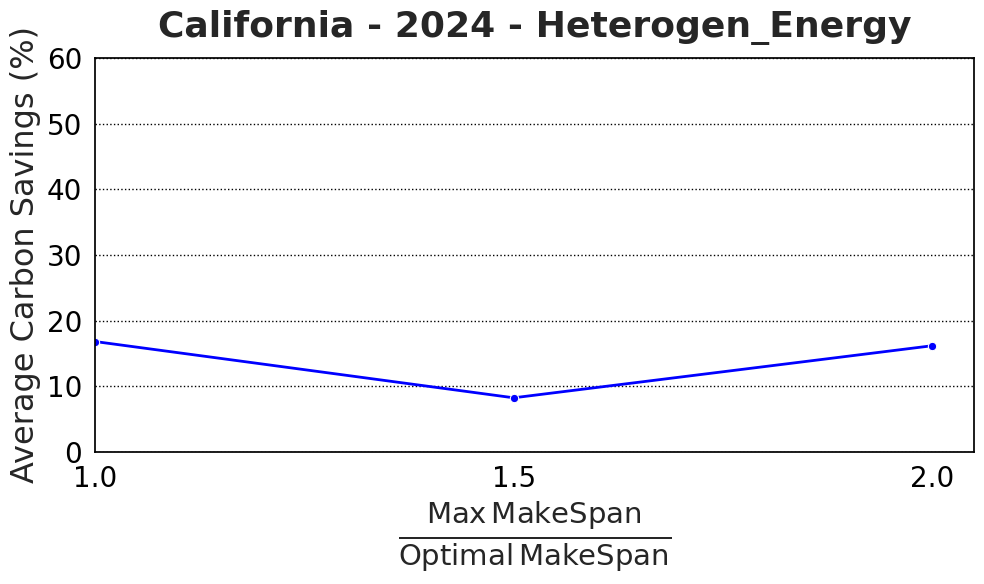

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import os

save_fig = False
save_file_path = f"./GeneralExpv2/{folder_type}/LinePlot-{location}.png"
directory = os.path.dirname(save_file_path)
os.makedirs(directory, exist_ok=True)

# Seaborn & matplotlib styling
sns.set(style="whitegrid", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})

# Ensure 'x_label' is treated as string (categorical)
df_plot["SlackCoeff"] = df_plot["SlackCoeff"].astype(str)

plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df_plot,
    x="SlackCoeff",
    y="CarbonSavings(%)",
    marker="o",
    linewidth=2,
    color="blue"
)

# Labels
ax.set_xlabel(r"$\frac{\mathrm{Max\,MakeSpan}}{\mathrm{Optimal\,MakeSpan}}$", fontsize=30)
ax.set_ylabel("Average Carbon Savings (%)", fontsize=23)

# Axis limits and tick font sizes
ax.set_ylim(0, 60)
ax.set_xlim(0)
ax.tick_params(axis='x', labelsize=20, color='black')
ax.tick_params(axis='y', labelsize=20, color='black')

# Add minor ticks on y-axis every 2 units
ax.yaxis.set_minor_locator(MultipleLocator(2))
ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')

# Grid settings
ax.grid(axis='x', visible=False)  # No x-grid
ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)

# Black border and ticks
ax.tick_params(axis='both', color='black', labelcolor='black')
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    
ax.set_title(f"{location} - 2024 - {folder_type}", fontsize=26, fontweight="bold", pad=15)

plt.tight_layout()
if save_fig:
    plt.savefig(save_file_path, dpi=300, bbox_inches='tight')
plt.show()

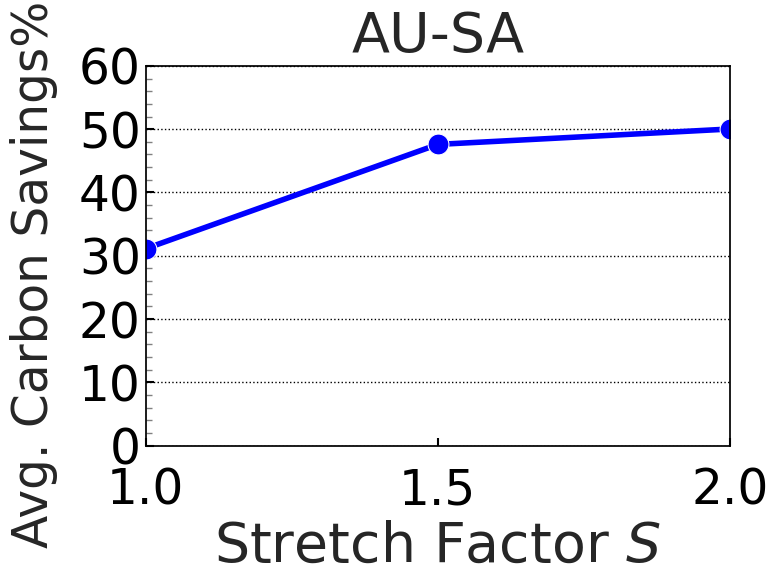

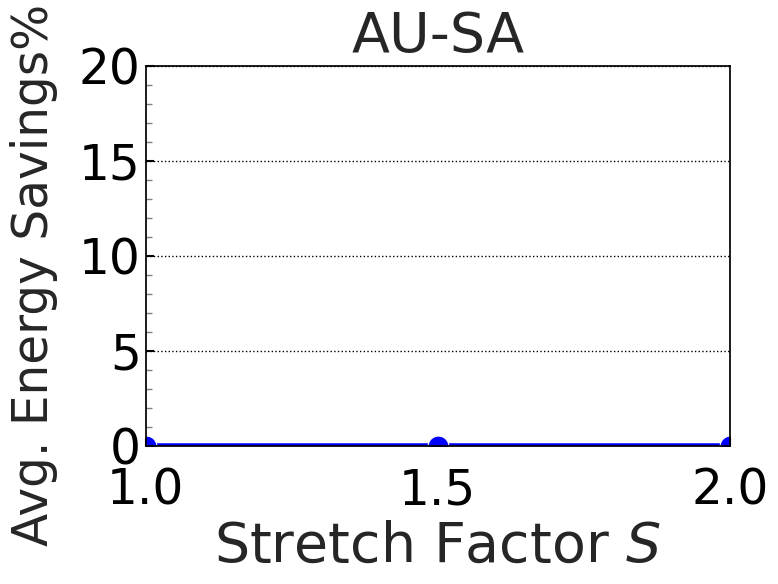

In [251]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import pandas as pd

###########
if location == "California":
    plot_title = "CAISO"
elif location == "AU-SA":
    plot_title = "AU-SA"
###########
save_fig = True
utilization_annotation = False
root_dir = f"./GeneralExpv2/{folder_type}/{location}"
########
save_data = True
if save_data:
    save_path = f"{root_dir}/{num_jobs}J_{num_servers}S_{num_operations}O_LinePlot_{plot_title}.csv"
    if mixed_objective:
        save_file_path = f"{root_dir}/{num_jobs}J_{num_servers}S_{num_operations}O_WithTieBreaker_LinePlot_{plot_title}.csv"
    directory = os.path.dirname(save_path)
    os.makedirs(directory, exist_ok=True)
    df_plot.to_csv(save_path, index = False)
###########
plot_types = ["Carbon Savings", "Energy Savings"]
column_names = ["CarbonSavings(%)", "EnergySavings(%)"]
for plot_index, plot_type in enumerate(plot_types):
    save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_{num_operations}O_LinePlot_{plot_title}.png"
    if mixed_objective:
        save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_{num_operations}O_WithTieBreaker_LinePlot_{plot_title}.png"
    directory = os.path.dirname(save_file_path)
    os.makedirs(directory, exist_ok=True)

    # Seaborn & matplotlib styling
    # sns.set(style="whitegrid", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    sns.set(style="ticks", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    # Reset rcParams that might affect ticks
    plt.rcParams['ytick.minor.visible'] = True
    # Ensure 'x_label' is treated as string (categorical)
    df_plot["SlackCoeff"] = df_plot["SlackCoeff"].astype(str)
    
    line_color = "blue"
    if folder_type in ["Heterogen_Energy"]:
        line_color = "red"

    plt.figure(figsize=(8, 6))
    ax = sns.lineplot(
        data=df_plot,
        x="SlackCoeff",
        y=column_names[plot_index],
        marker="o",
        markersize=15,
        linewidth=4,
        color=line_color
    )

    # Labels
    # ax.set_xlabel(r"$\frac{\mathrm{Max\,MakeSpan}}{\mathrm{Optimal\,MakeSpan}}$", fontsize=30)
    ax.set_xlabel(r"Stretch Factor $S$", fontsize=40)
    
    ax.set_ylabel(f"Avg. {plot_type}%", fontsize=35)
    ax.yaxis.set_label_coords(-0.15, 0.45)  # Move it 5% lower on the y-axis

    # Axis limits and tick font sizes
    if plot_type == "Carbon Savings":
        ax.set_ylim(0, 60)
        ax.set_yticks(range(0, 61, 10))
    else:
        ax.set_ylim(0, 20)
        ax.set_yticks(range(-0, 21, 5))
    ax.set_xlim(0, max(list(df_plot["SlackCoeff"])))
    ax.tick_params(axis='x', labelsize=35, color='black', pad=15)
    ax.tick_params(axis='y', labelsize=35, color='black')
    
    # Minor ticks
    ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')
    # Make major ticks point inward too
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.5)
    ax.xaxis.set_tick_params(which='minor', bottom=False)
    # Ensure minor ticks are visible
    plt.minorticks_on()

    # Grid settings
    ax.grid(axis='x', visible=False)  # No x-grid
    ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)
    # ax.grid(axis='y', which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.7)

    # Black border and ticks
    ax.tick_params(axis='both', color='black', labelcolor='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        
    ax.set_title(f"{plot_title}", fontsize=40, pad=10)

    # Annotate each point with UtilizationRatio
    if utilization_annotation:
        if plot_type == "Carbon Savings":
            for index, row in df_plot.iterrows():
                utilization_ratio = row['UtilizationRatio']
                x_pos = row['SlackCoeff']
                y_pos = row[column_names[plot_index]]
                
                # If it's the first point, adjust it slightly to the right
                if index == 0:
                    ax.text(float(x_pos) - 0.9, y_pos + 3, f"{utilization_ratio:.2f}%", 
                            color='black', fontsize=12, ha='center', va='bottom')
                else:
                    ax.text(x_pos, y_pos + 1.5, f"{utilization_ratio:.2f}%", 
                            color='black', fontsize=12, ha='center', va='bottom')

    plt.tight_layout()
    if save_fig:
        plt.savefig(save_file_path, dpi=300, bbox_inches='tight')
        pdf_save_path = save_file_path.replace(".png", ".pdf")
        plt.savefig(pdf_save_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

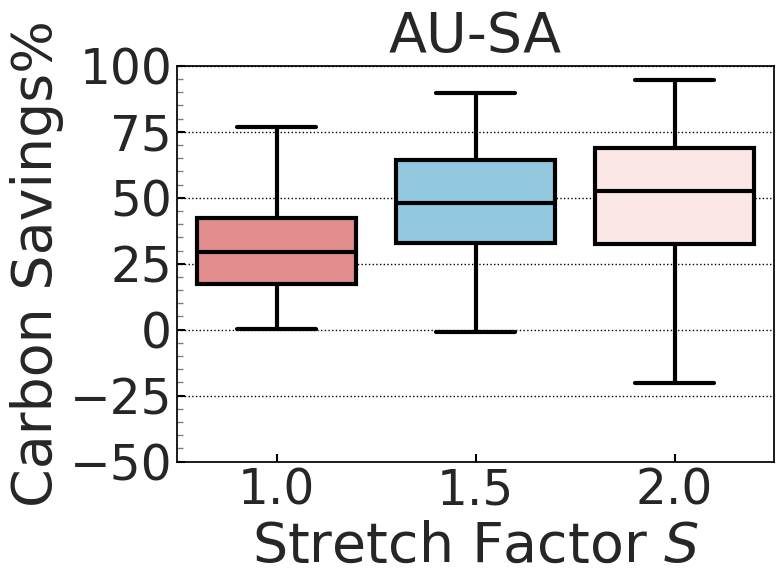

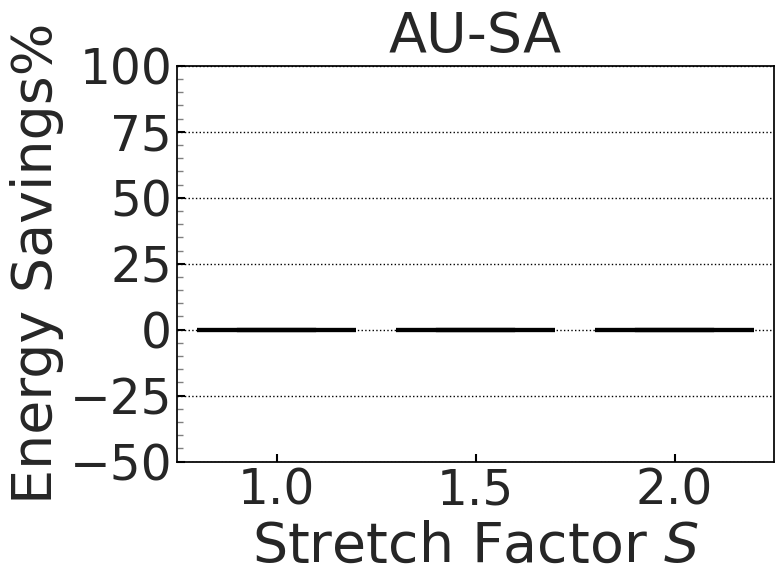

In [252]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import pandas as pd
###########
if location == "California":
    plot_title = "CAISO"
elif location == "AU-SA":
    plot_title = "AU-SA"
###########
save_fig = True
utilization_annotation = False
root_dir = f"./GeneralExpv2/{folder_type}/{location}"
########
df_box = df_logs[df_logs["IsCarbonAware"] == True].copy()
save_data = True
if save_data:
    save_path = f"{root_dir}/{num_jobs}J_{num_servers}S_{num_operations}O_BoxPlot_{plot_title}.csv"
    directory = os.path.dirname(save_path)
    os.makedirs(directory, exist_ok=True)
    df_plot.to_csv(save_path, index = False)
########
plot_types = ["Carbon Savings", "Energy Savings"]
column_names = ["CarbonSavings(%)", "EnergySavings(%)"]
for plot_index, plot_type in enumerate(plot_types):
    save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_{num_operations}O_BoxPlot_{plot_title}.png"
    if mixed_objective:
        save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_{num_operations}O_WithTieBreaker_BoxPlot_{plot_title}.png"
    directory = os.path.dirname(save_file_path)
    os.makedirs(directory, exist_ok=True)
    
    # Seaborn & matplotlib styling
    sns.set(style="ticks", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    plt.rcParams['ytick.minor.visible'] = True
    
    # Filter for carbon-aware runs only
    unique_labels = sorted(df_box["SlackCoeff"].unique())
    all_colors = ["lightseagreen", "khaki", "plum", "lightsalmon", "skyblue", "wheat", "orchid", "mistyrose", "lightcoral"]
    if folder_type in ["Heterogen", "Heterogen_Energy"]:
        inner_colors = ["lightseagreen", "khaki", "plum"]
    elif folder_type in ["Homogen", "Homogen_Energy"]:
        inner_colors = ["lightcoral", "skyblue", "mistyrose"]
    palette = inner_colors[:len(unique_labels)]
    df_box["SlackCoeff"] = df_box["SlackCoeff"].astype(str)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    box = sns.boxplot(
        data=df_box,
        x="SlackCoeff",
        y=column_names[plot_index],
        hue="SlackCoeff",
        palette=palette,
        dodge=False,
        legend=False,
        ax = ax
    )
    
    
    # Forcefully update the patches
    for patch in ax.patches:
        patch.set_linewidth(3)
        patch.set_edgecolor("black")

    # Manually adjust all the lines for whiskers, caps, and medians
    for line in ax.lines:
        line.set_linewidth(3)
        line.set_color("black")
    
    # Axis labels
    ax.set_xlabel(r"Stretch Factor $S$", fontsize=40)
    ax.set_ylabel(f"{plot_type}%", fontsize=40)

    # Axis ticks and limits
    ax.set_ylim(-50, 100)
    ax.set_yticks(range(-50, 101, 25))
    # ax.set_xlim(0, max(list(df_plot["SlackCoeff"])))
    ax.tick_params(axis='x', labelsize=35, color='black')
    ax.tick_params(axis='y', labelsize=35, color='black')

    # Minor ticks
    ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')
    # Make major ticks point inward too
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.5)
    ax.xaxis.set_tick_params(which='minor', bottom=False)
    # Ensure minor ticks are visible
    plt.minorticks_on()

    # Grid & borders
    ax.grid(axis='x', visible=False)
    ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
    ax.set_title(f"{plot_title}", fontsize=40, pad=10)
    plt.tight_layout()
    if save_fig:
        plt.savefig(save_file_path, dpi=300, bbox_inches='tight')
        pdf_save_path = save_file_path.replace(".png", ".pdf")
        plt.savefig(pdf_save_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

Caclulating p-value to see if the results are statistically significant or not

In [24]:
from scipy.stats import mannwhitneyu
import itertools
import pandas as pd

# Ensure SlackCoeff is treated numerically for correct sorting
df_box["SlackCoeff"] = df_box["SlackCoeff"].astype(float)

# Get all unique values of SlackCoeff
unique_slack_coeffs = sorted(df_box["SlackCoeff"].unique())

# Store p-values
pval_results = []

# Compute Mann–Whitney U test for each pair of SlackCoeff groups
for sc1, sc2 in itertools.combinations(unique_slack_coeffs, 2):
    data1 = df_box[df_box["SlackCoeff"] == sc1]["CarbonSavings(%)"]
    data2 = df_box[df_box["SlackCoeff"] == sc2]["CarbonSavings(%)"]
    
    stat, p = mannwhitneyu(data1, data2, alternative='two-sided')
    pval_results.append({
        "SlackCoeff 1": sc1,
        "SlackCoeff 2": sc2,
        "p-value": p
    })

# Convert to DataFrame for inspection
pval_df = pd.DataFrame(pval_results)
print(pval_df)

   SlackCoeff 1  SlackCoeff 2       p-value
0           1.0           1.5  2.694690e-01
1           1.0           2.0  4.307939e-18
2           1.5           2.0  6.622275e-22


## Line plot + Utilization

In [17]:
import pandas as pd
import glob
import os
# location = "Australia-WA"
location = "California"
folder_type = "Homogen"
# root_dir = f"../Logs/GeneralExp"
root_dir = f"../Logs/GeneralExp/{folder_type}/{location}/Uniform Random Job Arrival"
num_servers = 5

# Define the pattern
pattern = "10J_5S_3O_MeanOp=7_v*.csv"

# Get list of matching files
csv_files = glob.glob(f"{root_dir}/{pattern}")

# Read and concatenate all files
df_union = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

print(f"✅ Loaded and merged {len(csv_files)} files. Final shape: {df_union.shape}")

✅ Loaded and merged 8 files. Final shape: (4320, 23)


In [16]:
df_union.head(2)

,ElapsedTime,Datetime,Instance,IsCarbonAware,Horizon,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g),...,ServerPower,EpochDuration(min),SolverTimer(min),JobIndex,JobArrivalEpoch,Server0,Server1,Server2,Server3,Server4
0,0:00:00,2024-01-01,0,False,192,192,111,1.0,111,12887.25,...,"[1, 1, 1, 1, 1]",15,1,"['654', '114', '25', '759', '281', '250', '228...","[3, 13, 14, 17, 28, 31, 35, 81, 94, 94]","[[654, 0, 3, 10], [114, 0, 13, 29], [114, 1, 5...","[[654, 2, 21, 24], [25, 2, 49, 55], [759, 0, 1...","[[25, 1, 32, 35], [759, 1, 20, 22], [228, 1, 4...","[[142, 0, 81, 83], [142, 1, 83, 84]]","[[654, 1, 10, 21], [754, 1, 95, 104]]"
1,0:01:06,2024-01-01,0,True,192,111,111,1.0,111,7994.25,...,"[1, 1, 1, 1, 1]",15,1,"['654', '114', '25', '759', '281', '250', '228...","[3, 13, 14, 17, 28, 31, 35, 81, 94, 94]","[[654, 0, 72, 79], [228, 1, 79, 83], [228, 2, ...","[[114, 1, 92, 93], [25, 0, 77, 80], [759, 0, 7...","[[114, 0, 72, 88], [25, 2, 90, 96], [142, 0, 8...","[[25, 1, 87, 90], [759, 2, 82, 87], [281, 0, 7...","[[654, 1, 79, 90], [654, 2, 90, 93], [114, 2, ..."


In [49]:
import ast
df_utilization = df_union [["Instance", "IsCarbonAware", "SlackCoeff", "MaxMakeSpan", "MinMakeSpan", "Makespan"] + [f"Server{i}" for i in range(num_servers)]]
df_utilization = df_utilization[df_utilization["IsCarbonAware"] == True]
server_columns = [col for col in df_utilization.columns if col.startswith('Server')]
for col in server_columns:
    df_utilization[col] = df_utilization[col].apply(ast.literal_eval)

In [50]:
df_utilization.head(3)

,Instance,IsCarbonAware,SlackCoeff,MaxMakeSpan,MinMakeSpan,Makespan,Server0,Server1,Server2,Server3,Server4
1,0,True,1.0,111,111,111,"[[654, 0, 72, 79], [228, 1, 79, 83], [228, 2, ...","[[114, 1, 92, 93], [25, 0, 77, 80], [759, 0, 7...","[[114, 0, 72, 88], [25, 2, 90, 96], [142, 0, 8...","[[25, 1, 87, 90], [759, 2, 82, 87], [281, 0, 7...","[[654, 1, 79, 90], [654, 2, 90, 93], [114, 2, ..."
2,0,True,1.5,167,111,167,"[[654, 0, 69, 76], [114, 1, 164, 165], [114, 2...","[[114, 0, 79, 95], [250, 1, 78, 79], [228, 0, ...","[[281, 2, 80, 82], [228, 2, 82, 95], [142, 2, ...","[[759, 0, 75, 78], [250, 0, 71, 75], [250, 2, ...","[[654, 1, 76, 87], [654, 2, 160, 163], [25, 1,..."
3,0,True,2.0,192,111,184,"[[114, 1, 91, 92], [114, 2, 164, 166], [25, 2,...","[[654, 2, 165, 168], [114, 0, 75, 91], [281, 2...","[[228, 0, 78, 92], [228, 2, 168, 181]]","[[654, 0, 75, 82], [250, 2, 172, 180], [142, 0...","[[654, 1, 82, 93], [25, 0, 72, 75], [25, 1, 78..."


In [43]:
slack_coeffs = list(df_utilization["SlackCoeff"].unique())

In [62]:
util_ratios = {} # per instance
util_final_ratio = {} # average over all instances
for slack_coeff in slack_coeffs:
    df = df_utilization[df_utilization["SlackCoeff"] == slack_coeff]
    util_ratios[slack_coeff] = [] # per instance
    for index, row in df.iterrows(): # per instance
        servers_utilization = {}
        for serverID in range(num_servers):
            server_status = row[f"Server{serverID}"]
            server_util = 0
            for [job_id, operation_id, start, end] in server_status:
                server_util += (end - start) / row["MaxMakeSpan"]
            servers_utilization[serverID] = server_util
        # print(servers_utilization)
        util_ratios[slack_coeff].append(np.average(list(servers_utilization.values())))
        # print(util_ratios)
        # raise Exception ("S")
    util_final_ratio[slack_coeff] = round(np.average(util_ratios[slack_coeff]) * 100, 2)
# Convert keys and values to regular Python float
util_final_ratio = {float(k): float(v) for k, v in util_final_ratio.items()}
        

In [63]:
util_final_ratio

{1.0: 35.7, 1.5: 23.93, 2.0: 20.93}

# Plot2 - Effect of Number of Servers

In [32]:
import pandas as pd
import glob
import os
# location = "AU-SA"
location = "California"
#############
folder_type = "Homogen"
# folder_type = "Heterogen"
# folder_type = "Heterogen_Energy"
############
# root_dir = f"../Logs/GeneralExp"
root_dir = f"../Logs/GeneralExpv2/{folder_type}/{location}"
num_jobs = 10
list_num_servers = [5, 10, 15]
num_operations = 3
list_dfs = []
for num_servers in list_num_servers:
    # reading the df for a specific number of servers
    pattern = f"{num_jobs}J_{num_servers}S_{num_operations}O_MeanOp=7_v*.csv"
    csv_files = glob.glob(f"{root_dir}/{pattern}")
    df_logs = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)
    df_logs = df_logs[df_logs["SlackCoeff"] == 1]
    # Calculating the carbon and energy savings
    # First, get baseline carbon consumption per instance where IsCarbonAware is False
    baseline = df_logs[df_logs["IsCarbonAware"] == False][["Instance", "CarbonConsumption(g)", "EnergyConsumption(kWh)"]]
    baseline = baseline.rename(columns={"CarbonConsumption(g)": "BaselineCarbon", "EnergyConsumption(kWh)": "BaselineEnergy"})
    # Merge it back to original df to align baseline carbon for each instance
    df_logs = df_logs.merge(baseline, on="Instance", how="left")
    # Calculate savings
    df_logs["CarbonSavings(%)"] = ((df_logs["BaselineCarbon"] - df_logs["CarbonConsumption(g)"]) / df_logs["BaselineCarbon"]) * 100
    df_logs["EnergySavings(%)"] = ((df_logs["BaselineEnergy"] - df_logs["EnergyConsumption(kWh)"]) / df_logs["BaselineEnergy"]) * 100
    df_logs.drop(columns=["BaselineCarbon", "BaselineEnergy"], inplace=True)
    # Optional: round to 2 decimal places
    df_logs["CarbonSavings(%)"] = df_logs["CarbonSavings(%)"].round(2)
    df_logs["EnergySavings(%)"] = df_logs["EnergySavings(%)"].round(2)
    # adding to list of dfs
    list_dfs.append(df_logs)
    print(f"✅ Loaded and merged {len(csv_files)} files. Final shape: {df_logs.shape}")
df_union = pd.concat(list_dfs, ignore_index=True)
df_logs = df_union[["Instance", "ServerNumber", "IsCarbonAware", "MaxMakeSpan", "MinMakeSpan", "SlackCoeff", "Makespan", "CarbonConsumption(g)", "EnergyConsumption(kWh)", "CarbonSavings(%)", "EnergySavings(%)"]]
# df_union = df_union[df_union["SlackCoeff"] == 1]

✅ Loaded and merged 8 files. Final shape: (2160, 25)
✅ Loaded and merged 8 files. Final shape: (2160, 30)
✅ Loaded and merged 8 files. Final shape: (2160, 35)


In [34]:
len(df_logs)

6480

In [35]:
df_logs

,Instance,ServerNumber,IsCarbonAware,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g),EnergyConsumption(kWh),CarbonSavings(%),EnergySavings(%)
0,0,5,False,672,111,1.0,111,12887.25,37.50,0.00,0.0
1,0,5,True,111,111,1.0,111,7994.25,37.50,37.97,0.0
2,1,5,False,672,142,1.0,142,18906.25,58.00,0.00,0.0
3,1,5,True,142,142,1.0,142,14490.00,58.00,23.36,0.0
4,2,5,False,672,123,1.0,123,17032.75,60.50,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...
6475,1077,15,True,109,109,1.0,109,8970.00,57.25,29.66,0.0
6476,1078,15,False,672,87,1.0,87,8826.50,40.75,0.00,0.0
6477,1078,15,True,87,87,1.0,87,6088.50,40.75,31.02,0.0
6478,1079,15,False,672,95,1.0,95,10578.50,54.00,0.00,0.0


In [37]:
import pandas as pd

# Filter only carbon-aware rows
df_filtered = df_logs[df_logs["IsCarbonAware"] == True].copy()
df_carbon_savings = df_filtered.groupby("ServerNumber")["CarbonSavings(%)"].mean().reset_index()
df_energy_savings = df_filtered.groupby("ServerNumber")["EnergySavings(%)"].mean().reset_index()
df_plot = pd.merge(df_carbon_savings, df_energy_savings, on="ServerNumber")
# df_plot['UtilizationRatio'] = df_plot['SlackCoeff'].map(util_final_ratio)

In [38]:
df_plot

,ServerNumber,CarbonSavings(%),EnergySavings(%)
0,5,26.956583,0.0
1,10,30.566889,0.0
2,15,29.314083,0.0


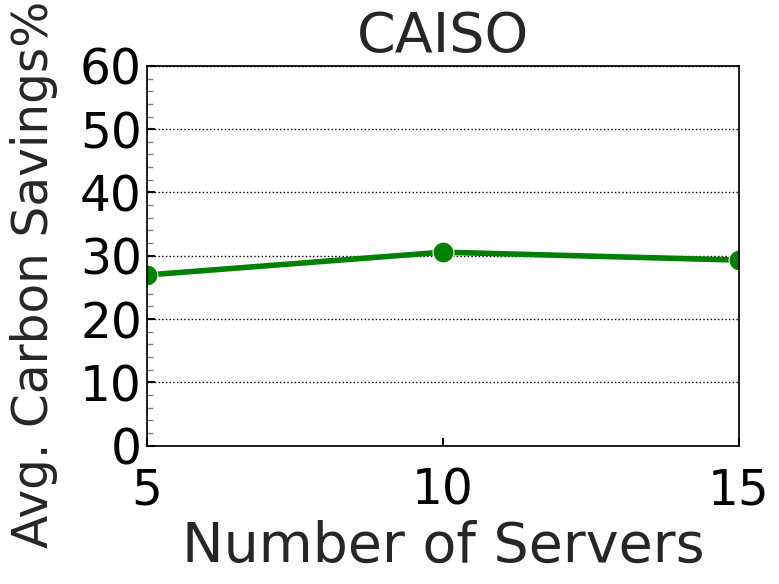

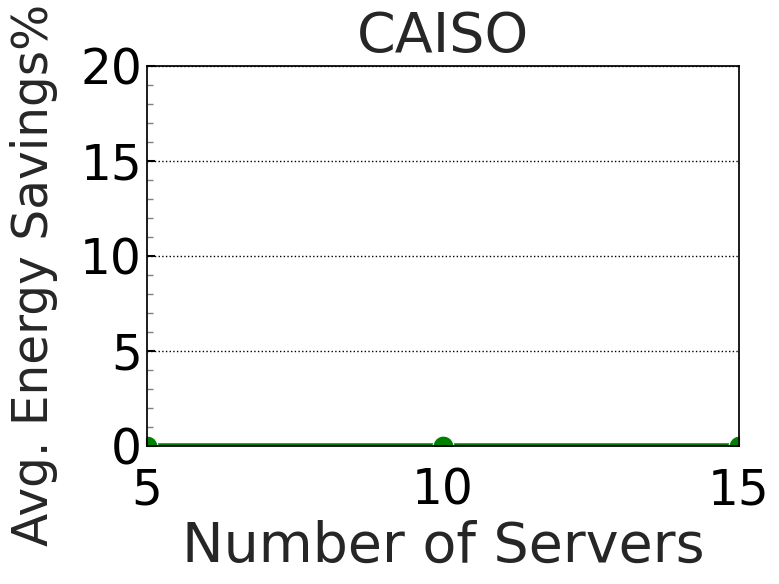

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import pandas as pd

###########
if location == "California":
    plot_title = "CAISO"
elif location == "AU-SA":
    plot_title = "AU-SA"
###########
save_fig = True
utilization_annotation = False
root_dir = f"./Effect of Parameters/Number of Servers/{folder_type}/{location}"
########
save_data = True
if save_data:
    save_path = f"{root_dir}/{num_jobs}J_{num_servers}S_{num_operations}O_LinePlot_{plot_title}.csv"
    # if mixed_objective:
    #     save_file_path = f"{root_dir}/{num_jobs}J_{num_servers}S_{num_operations}O_WithTieBreaker_LinePlot_{plot_title}.csv"
    directory = os.path.dirname(save_path)
    os.makedirs(directory, exist_ok=True)
    df_plot.to_csv(save_path, index = False)
###########
plot_types = ["Carbon Savings", "Energy Savings"]
column_names = ["CarbonSavings(%)", "EnergySavings(%)"]
for plot_index, plot_type in enumerate(plot_types):
    save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_{num_operations}O_LinePlot_{plot_title}.png"
    directory = os.path.dirname(save_file_path)
    os.makedirs(directory, exist_ok=True)

    # Seaborn & matplotlib styling
    # sns.set(style="whitegrid", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    sns.set(style="ticks", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    # Reset rcParams that might affect ticks
    plt.rcParams['ytick.minor.visible'] = True
    # Ensure 'x_label' is treated as string (categorical)
    df_plot["ServerNumber"] = df_plot["ServerNumber"].astype(str)
    
    line_color = "green"
    if folder_type in ["Heterogen_Energy"]:
        line_color = "red"

    plt.figure(figsize=(8, 6))
    ax = sns.lineplot(
        data=df_plot,
        x="ServerNumber",
        y=column_names[plot_index],
        marker="o",
        markersize=15,
        linewidth=4,
        color=line_color
    )

    # Labels
    # ax.set_xlabel(r"$\frac{\mathrm{Max\,MakeSpan}}{\mathrm{Optimal\,MakeSpan}}$", fontsize=30)
    ax.set_xlabel(r"Number of Servers", fontsize=40)
    
    ax.set_ylabel(f"Avg. {plot_type}%", fontsize=35)
    ax.yaxis.set_label_coords(-0.15, 0.45)  # Move it 5% lower on the y-axis

    # Axis limits and tick font sizes
    if plot_type == "Carbon Savings":
        ax.set_ylim(0, 60)
        ax.set_yticks(range(0, 61, 10))
    else:
        ax.set_ylim(0, 20)
        ax.set_yticks(range(-0, 21, 5))
    ax.set_xlim(0, len(list(df_plot["ServerNumber"]))-1)
    ax.tick_params(axis='x', labelsize=35, color='black', pad=15)
    ax.tick_params(axis='y', labelsize=35, color='black')
    
    # Minor ticks
    ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')
    # Make major ticks point inward too
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.5)
    ax.xaxis.set_tick_params(which='minor', bottom=False)
    # Ensure minor ticks are visible
    plt.minorticks_on()

    # Grid settings
    ax.grid(axis='x', visible=False)  # No x-grid
    ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)
    # ax.grid(axis='y', which='minor', color='gray', linestyle=':', linewidth=0.5, alpha=0.7)

    # Black border and ticks
    ax.tick_params(axis='both', color='black', labelcolor='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        
    ax.set_title(f"{plot_title}", fontsize=40, pad=10)

    # Annotate each point with UtilizationRatio
    if utilization_annotation:
        if plot_type == "Carbon Savings":
            for index, row in df_plot.iterrows():
                utilization_ratio = row['UtilizationRatio']
                x_pos = row['ServerNumber']
                y_pos = row[column_names[plot_index]]
                
                # If it's the first point, adjust it slightly to the right
                if index == 0:
                    ax.text(float(x_pos) - 0.9, y_pos + 3, f"{utilization_ratio:.2f}%", 
                            color='black', fontsize=12, ha='center', va='bottom')
                else:
                    ax.text(x_pos, y_pos + 1.5, f"{utilization_ratio:.2f}%", 
                            color='black', fontsize=12, ha='center', va='bottom')

    plt.tight_layout()
    if save_fig:
        plt.savefig(save_file_path, dpi=300, bbox_inches='tight')
        pdf_save_path = save_file_path.replace(".png", ".pdf")
        plt.savefig(pdf_save_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

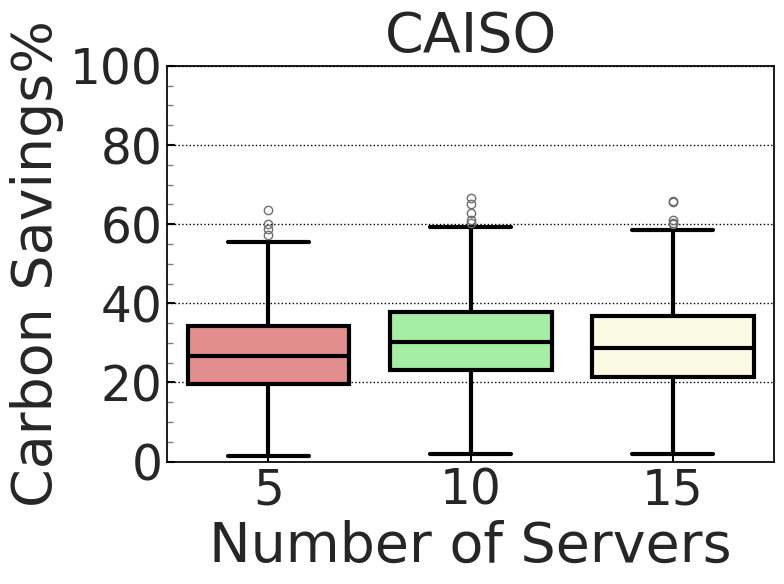

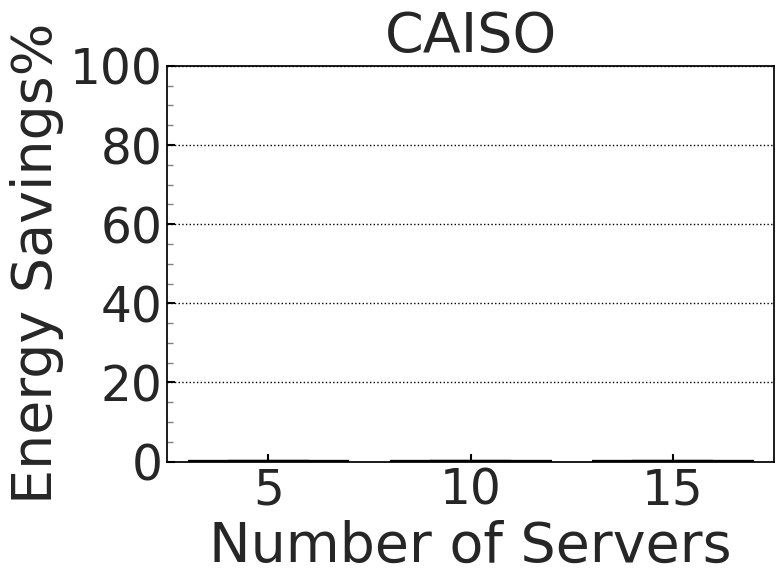

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
import pandas as pd
###########
if location == "California":
    plot_title = "CAISO"
elif location == "AU-SA":
    plot_title = "AU-SA"
###########
save_fig = True
utilization_annotation = False
root_dir = f"./Effect of Parameters/Number of Servers/{folder_type}/{location}"
########
df_box = df_logs[df_logs["IsCarbonAware"] == True].copy()
save_data = False
if save_data:
    save_path = f"{root_dir}/{num_jobs}J_{num_servers}S_{num_operations}O_BoxPlot_{plot_title}.csv"
    directory = os.path.dirname(save_path)
    os.makedirs(directory, exist_ok=True)
    df_plot.to_csv(save_path, index = False)
########
plot_types = ["Carbon Savings", "Energy Savings"]
column_names = ["CarbonSavings(%)", "EnergySavings(%)"]
for plot_index, plot_type in enumerate(plot_types):
    save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_{num_operations}O_BoxPlot_{plot_title}v2.png"
    # if mixed_objective:
    #     save_file_path = f"{root_dir}/{plot_type}_{num_jobs}J_{num_servers}S_{num_operations}O_WithTieBreaker_BoxPlot_{plot_title}.png"
    directory = os.path.dirname(save_file_path)
    os.makedirs(directory, exist_ok=True)
    
    # Seaborn & matplotlib styling
    sns.set(style="ticks", font="DejaVu Sans", rc={"mathtext.fontset": "dejavusans"})
    plt.rcParams['ytick.minor.visible'] = True
    
    # Filter for carbon-aware runs only
    unique_labels = sorted(df_box["ServerNumber"].unique())
    all_colors = ["lightseagreen", "khaki", "plum", "lightsalmon", "skyblue", "wheat", "orchid", "mistyrose", "lightcoral"]
    if folder_type in ["Heterogen", "Heterogen_Energy"]:
        inner_colors = ["lightseagreen", "khaki", "plum"]
    elif folder_type in ["Homogen", "Homogen_Energy"]:
        # inner_colors = ["lightcoral", "skyblue", "mistyrose"]
        # inner_colors = ["lightcoral", "wheat", "orchid"]
        inner_colors = ["lightcoral", "palegreen", "lightyellow"]
    palette = inner_colors[:len(unique_labels)]
    df_box["ServerNumber"] = df_box["ServerNumber"].astype(str)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 6))
    box = sns.boxplot(
        data=df_box,
        x="ServerNumber",
        y=column_names[plot_index],
        hue="ServerNumber",
        palette=palette,
        dodge=False,
        legend=False,
        ax = ax
    )
    
    
    # Forcefully update the patches
    for patch in ax.patches:
        patch.set_linewidth(3)
        patch.set_edgecolor("black")

    # Manually adjust all the lines for whiskers, caps, and medians
    for line in ax.lines:
        line.set_linewidth(3)
        line.set_color("black")
    
    # Axis labels
    ax.set_xlabel(r"Number of Servers", fontsize=40)
    ax.set_ylabel(f"{plot_type}%", fontsize=40)

    # Axis ticks and limits
    # ax.set_ylim(-50, 100)
    ax.set_ylim(0, 100)
    # ax.set_yticks(range(-50, 101, 25))
    ax.set_yticks(range(0, 101, 20))
    ax.tick_params(axis='x', labelsize=35, color='black')
    ax.tick_params(axis='y', labelsize=35, color='black')

    # Minor ticks
    ax.tick_params(axis='y', which='minor', direction='in', length=4, color='gray')
    # Make major ticks point inward too
    ax.tick_params(axis='both', which='major', direction='in', length=6, width=1.5)
    ax.xaxis.set_tick_params(which='minor', bottom=False)
    # Ensure minor ticks are visible
    plt.minorticks_on()

    # Grid & borders
    ax.grid(axis='x', visible=False)
    ax.grid(axis='y', which='major', color='black', linestyle=':', linewidth=1)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
    ax.set_title(f"{plot_title}", fontsize=40, pad=10)
    plt.tight_layout()
    if save_fig:
        plt.savefig(save_file_path, dpi=300, bbox_inches='tight')
        pdf_save_path = save_file_path.replace(".png", ".pdf")
        plt.savefig(pdf_save_path, format='pdf', dpi=300, bbox_inches='tight')
    plt.show()

# Plot4 - Server activity plots

In [91]:
import pandas as pd
import glob
import os
# location = "AU-SA"
location = "California"
#############
folder_type = "Homogen"
# folder_type = "Heterogen"
# folder_type = "Heterogen_Energy"
############
# root_dir = f"../Logs/GeneralExp"
root_dir = f"../Logs/GeneralExpv2/{folder_type}/{location}"
num_jobs = 10
num_servers = 5
#############

# Define the pattern
pattern = f"{num_jobs}J_{num_servers}S_3O_MeanOp=7_v*.csv"

# Get list of matching files
csv_files = glob.glob(f"{root_dir}/{pattern}")

# Read and concatenate all files
df_union = pd.concat((pd.read_csv(f) for f in csv_files), ignore_index=True)

print(f"✅ Loaded and merged {len(csv_files)} files. Final shape: {df_union.shape}")

✅ Loaded and merged 8 files. Final shape: (4320, 23)


In [92]:
import ast
df_server_activity = df_union[(df_union["Instance"] == 0) & (df_union["SlackCoeff"] == 1)]
df_server_activity = df_server_activity.drop(columns=['ServerNumber', 'ServerPower'])
server_columns = [col for col in df_server_activity.columns if col.startswith('Server')]
for col in server_columns:
    df_server_activity[col] = df_server_activity[col].apply(ast.literal_eval)

In [93]:
df_server_activity

,ElapsedTime,Datetime,Instance,IsCarbonAware,MaxMakeSpan,MinMakeSpan,SlackCoeff,Makespan,CarbonConsumption(g),EnergyConsumption(kWh),...,OperationsPerJob,EpochDuration(min),SolverTimer(min),JobIndex,JobArrivalEpoch,Server0,Server1,Server2,Server3,Server4
0,0:00:00,2024-01-01,0,False,672,111,1.0,111,12887.25,37.5,...,3,15,1,"['654', '114', '25', '759', '281', '250', '228...","[3, 13, 14, 17, 28, 31, 35, 81, 94, 94]","[[654, 0, 3, 10], [114, 0, 13, 29], [114, 1, 5...","[[654, 2, 21, 24], [25, 2, 49, 55], [759, 0, 1...","[[25, 1, 32, 35], [759, 1, 20, 22], [228, 1, 4...","[[142, 0, 81, 83], [142, 1, 83, 84]]","[[654, 1, 10, 21], [754, 1, 95, 104]]"
1,0:01:06,2024-01-01,0,True,111,111,1.0,111,7994.25,37.5,...,3,15,1,"['654', '114', '25', '759', '281', '250', '228...","[3, 13, 14, 17, 28, 31, 35, 81, 94, 94]","[[114, 0, 75, 91], [114, 1, 91, 92], [114, 2, ...","[[759, 0, 72, 75], [759, 1, 83, 85], [250, 0, ...","[[25, 1, 80, 83], [250, 1, 79, 80], [228, 0, 6...","[[654, 0, 72, 79], [654, 2, 93, 96], [25, 2, 8...","[[654, 1, 79, 90], [759, 2, 90, 95], [281, 0, ..."


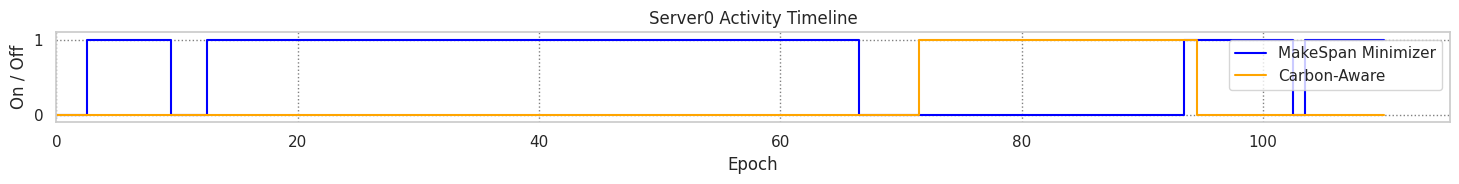

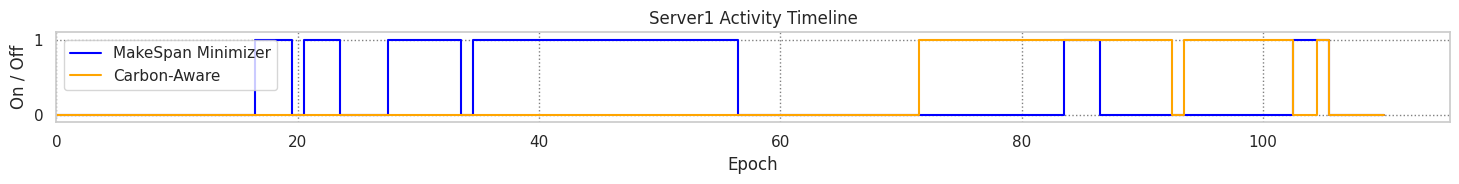

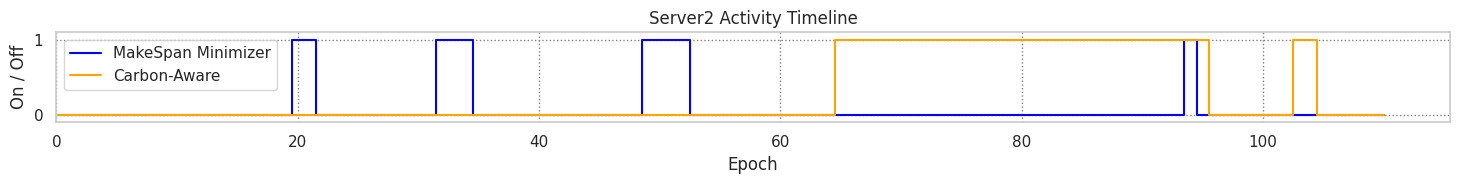

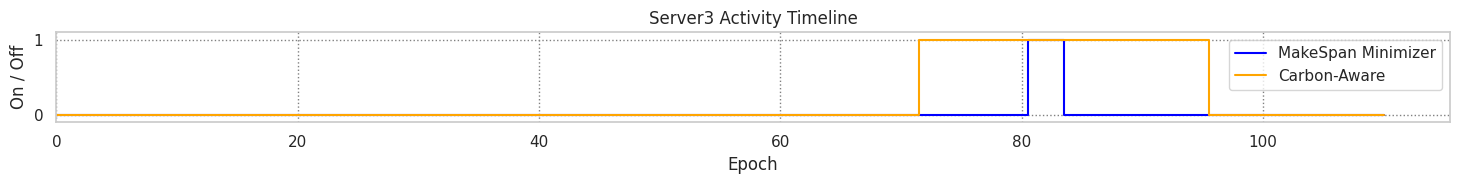

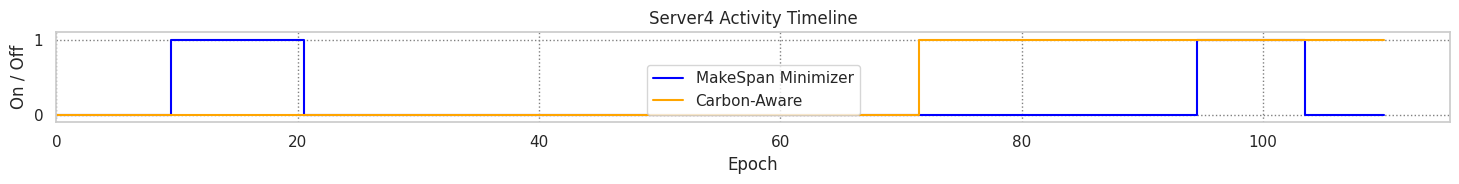

In [94]:
import matplotlib.pyplot as plt
import numpy as np

save_fig = True
# Get the list of servers from the dataframe
server_columns = [col for col in df_server_activity.columns if col.startswith("Server")]
colors = ['blue', 'orange']  # Colors for different rows
labels = ["MakeSpan Minimizer", "Carbon-Aware"]
# Iterate over each server
for server_id in server_columns:
    plt.figure(figsize=(15, 2))
    
    # Iterate over each row (max 2 rows for this plot)
    for index, (row, color) in enumerate(zip(df_server_activity.iterrows(), colors)):
        row_data = row[1]
        min_makespan = row_data["MinMakeSpan"]
        server_status = row_data[server_id]
        
        # Initialize the time series with zeros
        timeline = np.zeros(min_makespan)
        
        # If the data is a string, we eval it
        if isinstance(server_status, str):
            server_status = eval(server_status)

        # Set the periods where the server is active to 1
        for [job_id, operation_id, start, end] in server_status:
            timeline[start:end] = 1
        
        # Plot
        plt.step(range(min_makespan), timeline, where='mid', color=color, label=labels[index])
    
    plt.ylim(-0.1, 1.1)
    plt.xlim(left=0)
    plt.title(f"{server_id} Activity Timeline")
    plt.ylabel("On / Off")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid(True, linestyle=':', color='gray')
    plt.tight_layout()
    if save_fig:
        plt.savefig(f"./ServersActivity/{folder_type}/{location}/Server{server_id}.png", dpi=300, bbox_inches='tight')
    plt.show()